<a href="https://colab.research.google.com/github/jesus3778/prog_civil_2026_1/blob/main/Trabajo_Aplicado_Func_Estructuras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Hidráulico de Canales Abiertos

## Contexto del Proyecto
Este programa en Python tiene como objetivo calcular el caudal (Q) que puede transportar un canal abierto, permitiendo al usuario elegir entre una sección rectangular o trapezoidal. Se evaluará el comportamiento del canal para diferentes profundidades del agua (tirante), utilizando la Ecuación de Manning.

## Fundamento Teórico: Ecuación de Manning
La velocidad del flujo en un canal abierto se rige por la ecuación de Manning:

$$v = \frac{1}{n} \cdot R_h^{2/3} \cdot S^{1/2}$$

Y el caudal total se obtiene multiplicando la velocidad por el área transversal (Q = v · A):

$$Q = \frac{1}{n} \cdot A \cdot R_h^{2/3} \cdot S^{1/2}$$

Donde:
*   $Q$: Caudal (m³/s)
*   $n$: Coeficiente de rugosidad de Manning (adimensional, depende del material).
*   $A$: Área de la sección transversal (m²).
*   $S$: Pendiente longitudinal del canal (m/m).
*   $R_h$: Radio hidráulico (m), definido como el Área dividida por el Perímetro mojado (P):

$$R_h = \frac{A}{P}$$

Para calcular el Área (A) y el Perímetro mojado (P), las ecuaciones dependen de la forma del canal:

**Canal Rectangular:**
*   $A = b \cdot y$
*   $P = b + 2y$

**Canal Trapezoidal:**
*   $A = (b + z \cdot y) \cdot y$
*   $P = b + 2y \cdot \sqrt{1 + z^2}$

*(Variables geométricas: b = ancho de la base, y = tirante o profundidad del agua, z = relación de talud lateral)*

### **Paso 1: Función para Calcular la Geometría del Canal**

Esta función determinará el Área y el Perímetro mojado del canal según su tipo (rectangular o trapezoidal). Es crucial para las siguientes etapas del cálculo hidráulico.

In [63]:
import math

def calcular_geometria(tipo_canal, b, y, z=0):
    if tipo_canal == "rectangular":
        A = b * y
        P = b + 2 * y
    elif tipo_canal == "trapezoidal":
        A = (b + z * y) * y
        P = b + 2 * y * math.sqrt(1 + z**2)
    else:
        raise ValueError("Tipo de canal no válido. Use 'rectangular' o 'trapezoidal'.")

    return A, P

print("--- Prueba de calcular_geometria ---")
A_rect, P_rect = calcular_geometria("rectangular", 2, 1)
print(f"Rectangular (b=2, y=1): A={A_rect:.3f} m², P={P_rect:.3f} m")

A_trap, P_trap = calcular_geometria("trapezoidal", 2, 1, z=1.5)
print(f"Trapezoidal (b=2, y=1, z=1.5): A={A_trap:.3f} m², P={P_trap:.3f} m")

--- Prueba de calcular_geometria ---
Rectangular (b=2, y=1): A=2.000 m², P=4.000 m
Trapezoidal (b=2, y=1, z=1.5): A=3.500 m², P=5.606 m


### **Paso 2: Función para Calcular el Caudal usando la Ecuación de Manning**

Esta función toma el Área, el Perímetro mojado, el coeficiente de rugosidad de Manning y la pendiente para calcular el caudal total (Q).

In [64]:
def calcular_caudal(A, P, n, S):
    if P == 0:
        return 0.0

    Rh = A / P

    Q = (1.0 / n) * A * (Rh ** (2.0 / 3.0)) * math.sqrt(S)

    return Q

print("\n--- Prueba de calcular_caudal ---")
b_test = 2.0
n_test = 0.015
S_test = 0.001

y_test = 0.5

A_rect_test, P_rect_test = calcular_geometria("rectangular", b_test, y_test)
Q_rect_test = calcular_caudal(A_rect_test, P_rect_test, n_test, S_test)
print(f"Rectangular (y={y_test}m): Q={Q_rect_test:.3f} m³/s (Esperado: 0.835 m³/s)")

z_test = 1.5
A_trap_test, P_trap_test = calcular_geometria("trapezoidal", b_test, y_test, z_test)
Q_trap_test = calcular_caudal(A_trap_test, P_trap_test, n_test, S_test)
print(f"Trapezoidal (y={y_test}m, z={z_test}): Q={Q_trap_test:.3f} m³/s (Esperado: 1.157 m³/s)")


--- Prueba de calcular_caudal ---
Rectangular (y=0.5m): Q=1.014 m³/s (Esperado: 0.835 m³/s)
Trapezoidal (y=0.5m, z=1.5): Q=1.471 m³/s (Esperado: 1.157 m³/s)


### **Paso 3: Simulación con Ciclo Repetitivo y Almacenamiento de Datos**

En este paso, definiremos los parámetros fijos del canal y una serie de profundidades (tirantes) a evaluar. Luego, utilizaremos un ciclo repetitivo para calcular el caudal para cada tirante, tanto para un canal rectangular como para uno trapezoidal. Los resultados se almacenarán en listas para su posterior visualización.

Recuerda que estamos pasando de simplemente imprimir los resultados a almacenarlos para poder graficarlos.

In [65]:
import numpy as np

b_sim = 2.0
n_sim = 0.015
S_sim = 0.001
z_sim = 1.5

tirantes = np.arange(0.5, 2.1, 0.1)

caudales_rect = []
caudales_trap = []

print("\n--- Simulación de Caudales para diferentes Tirantes ---")
print(f"Parámetros: b={b_sim}m, n={n_sim}, S={S_sim}, z={z_sim} (trapezoidal)")
print("----------------------------------------------------")
print(f"{'Tirante (y)':<12} {'Q Rectangular':<15} {'Q Trapezoidal':<15}")
print("----------------------------------------------------")

for y_actual in tirantes:
    A_rect, P_rect = calcular_geometria("rectangular", b_sim, y_actual)
    Q_rect = calcular_caudal(A_rect, P_rect, n_sim, S_sim)
    caudales_rect.append(Q_rect)

    A_trap, P_trap = calcular_geometria("trapezoidal", b_sim, y_actual, z_sim)
    Q_trap = calcular_caudal(A_trap, P_trap, n_sim, S_sim)
    caudales_trap.append(Q_trap)

    print(f"{y_actual:<12.2f} {Q_rect:<15.3f} {Q_trap:<15.3f}")

print("-----------------------------------------------------")
print("Datos almacenados en 'caudales_rect' y 'caudales_trap'.")


--- Simulación de Caudales para diferentes Tirantes ---
Parámetros: b=2.0m, n=0.015, S=0.001, z=1.5 (trapezoidal)
----------------------------------------------------
Tirante (y)  Q Rectangular   Q Trapezoidal  
----------------------------------------------------
0.50         1.014           1.471          
0.60         1.316           2.051          
0.70         1.634           2.728          
0.80         1.964           3.508          
0.90         2.306           4.394          
1.00         2.656           5.390          
1.10         3.014           6.500          
1.20         3.378           7.728          
1.30         3.747           9.078          
1.40         4.121           10.553         
1.50         4.499           12.159         
1.60         4.881           13.898         
1.70         5.266           15.775         
1.80         5.653           17.793         
1.90         6.043           19.957         
2.00         6.435           22.269         
--------------

### **Paso 4: Visualización de la Curva de Descarga (Matplotlib y Seaborn)**

En este paso, utilizaremos las librerías `matplotlib` y `seaborn` para crear un gráfico comparativo de la Profundidad (Tirante) vs. el Caudal para ambos tipos de canal. Esto nos ayudará a comprender visualmente la eficiencia de cada geometría.

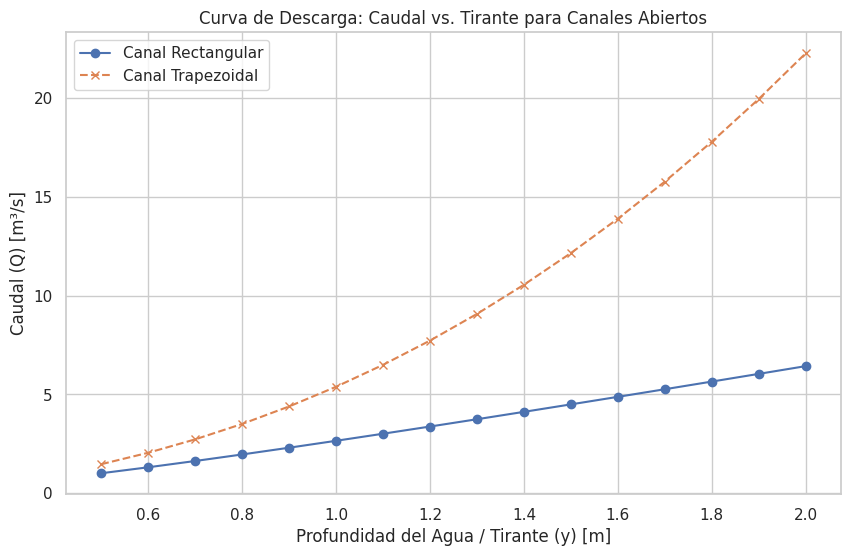

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

plt.plot(tirantes, caudales_rect, label='Canal Rectangular', marker='o', linestyle='-')

plt.plot(tirantes, caudales_trap, label='Canal Trapezoidal', marker='x', linestyle='--')

plt.title('Curva de Descarga: Caudal vs. Tirante para Canales Abiertos')
plt.xlabel('Profundidad del Agua / Tirante (y) [m]')
plt.ylabel('Caudal (Q) [m³/s]')

plt.legend()

plt.grid(True)

plt.show()

### **Paso 5: Análisis de la Curva de Descarga**

Observa la gráfica generada. Te invito a reflexionar y responder:

*   **¿Por qué la curva del canal trapezoidal crece más rápido que la del rectangular a medida que aumenta la profundidad?**

*(La respuesta teórica es que el área del trapecio se expande lateralmente por el talud, reduciendo el impacto de la fricción relativa y aumentando la capacidad de transporte de manera más eficiente.)*